## **TigerQuant: Intro to Pairs Trading** 
#### by Max Meystrik
---


We wil cover what pairs trading is, stationarity, co-integration, unit-root testing, and an implementation with yfinance.

#### **Motivation**

Pairs trading is market neutral mean reversion strategy. Imagine you have two securities (could be stocks, fixed income, commodities, etc.) with an intrinsic link. We can model this link and and trade based off of their relationship. 

We now cover stationarity, co-integration, and unit-root testing.

#### **Stationarity**

**Strict Stationarity**: 

A time series $x_t$ is strictly stationary if the random vectors of values
$ \{x_{i_{1}}, x_{i_{2}}, \ldots, x_{i_{k}}\}$ and $\{x_{i_{1+n}},x_{i_{2+n}}, \ldots, x_{i_{k+n}} \}$ have the same probabilistic behavior for all $k=1, 2, \ldots,$ all time points, and all shifts, i.e., the same distributions.

This is nearly impossible to determine in the real world, so weak stationarity is used in practice. Note, weak stationarity does not imply strict stationarity. 

**Weak Stationarity**: 

A weakly stationary time sereis (say $x_t$) is a finite variance process where

$$
E[x_t] = \mu_{t} < \infty 
$$
, i.e., the mean value $\mu_{t}$ is constant and does not depend on time and

$$
E[(x_t - \mu_{t})(x_{t+h} - \mu_{t})] = \gamma (h)
$$

for all $t$, i.e., the autocovariance function $\gamma(h)$ only depends on lag $h$.

Note that autocovariance the linear dependence between two points
on the same series observed at different times (a lag).

We visualize this below.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import libraries for data handling, math, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Function to generate a random value from a normal distribution
def generate_data(params):
    mu = params[0]
    sigma = params[1]
    return np.random.normal(mu, sigma)


# Define base parameters and time horizon T = 100
params = (0, 1)
T = 100


# Create empty Series A
A = pd.Series(index=range(T))
A.name = 'A'


# Generate stationary data (mean and variance constant)
for t in range(T):
    A[t] = generate_data(params)


# Create empty Series B
B = pd.Series(index=range(T))
B.name = 'B'


# Generate non-stationary data (mean changes over time)
for t in range(T):
    params = (t * 0.1, 1) # We 'change' mu as we traverse time
    B[t] = generate_data(params)


# Plot
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16,6))
ax1.plot(A)
ax2.plot(B)
ax1.legend(['Series A'])
ax2.legend(['Series B'])
ax1.set_title('Stationary')
ax2.set_title('Non-Stationary')

ModuleNotFoundError: No module named 'matplotlib'

**Why Stationary?**

If not, then results are sometimes meaningless. For example, see the mean of our non stationary time series below. 

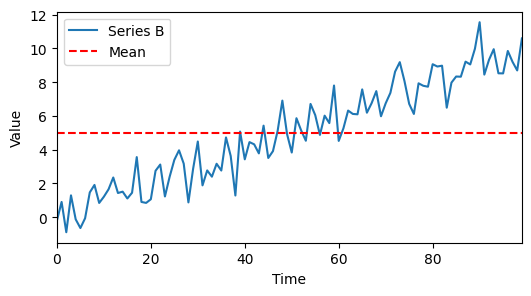

In [2]:
mean = np.mean(B)

plt.figure(figsize=(6,3))
plt.plot(B)
plt.hlines(mean, 0, len(B), linestyles='dashed', colors = 'r')
plt.xlabel('Time')
plt.xlim([0, 99])
plt.ylabel('Value')
plt.legend(['Series B', 'Mean'])

This mean does not show the full picture of our time series.

However, we can transform time series through methods like differencing. Note how this time series appears visually more stationary.

We do this by differencing, written mathematically as $\Delta Y_t = Y_t - Y_{t-1}$. This helps remove deterministic or trends in non-stationary data.

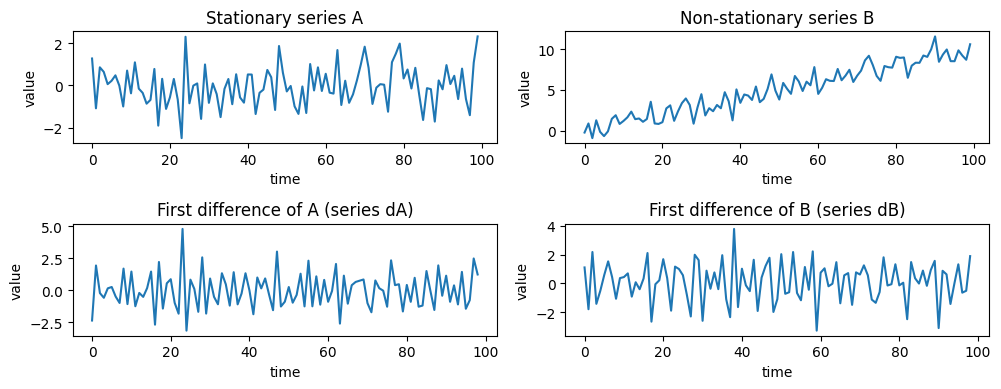

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set a seed for code result replication

np.random.seed(42)

T = 300


# Take first differences and graph

dA = A.diff().dropna()
dA.name = "A"
dB = B.diff().dropna()
dB.name = "B"

fig, axes = plt.subplots(2, 2, figsize=(10, 4))  

axes[0, 0].plot(A.values)
axes[0, 0].set_title("Stationary series A")
axes[0, 0].set_xlabel("time")
axes[0, 0].set_ylabel("value")

axes[0, 1].plot(B.values)
axes[0, 1].set_title("Non-stationary series B")
axes[0, 1].set_xlabel("time")
axes[0, 1].set_ylabel("value")

axes[1, 0].plot(dA.values)
axes[1, 0].set_title("First difference of A (series dA)")
axes[1, 0].set_xlabel("time")
axes[1, 0].set_ylabel("value")

axes[1, 1].plot(dB.values)
axes[1, 1].set_title("First difference of B (series dB)")
axes[1, 1].set_xlabel("time")
axes[1, 1].set_ylabel("value")

plt.tight_layout()
plt.show()






To recap, we want stationarity to allow us to better model our time series. This improves our ability to forecast. We will later show how to test for stationarity.  

Now, let's jump to how we examine two time series together.

##### **Co-integration**

**Co-integration** is the linear relationship between two time series with constant mean and standard deviation.


We can write this mathematically. But we first define the **order of integration** as follows. 

For a time series differenced $d-1$ times, $\{\nabla^{d-1}x_t\}$, is non stationary, but stationary for $\{\nabla^{d}x_t\}$, then $x_t$ is considered integrated of order $d$, denoted $x_t \sim I(d)$.

We say, 

$$
X_t \text{ is } I(0) \iff \Delta X_t = X_t - X_{t-1} \text{ is } I(0) \text{.}
$$

Now, we define co-integration more rigorously.

The components of vector $x_t = \{x_{t1}, \ldots, x_{tn}\}$  are cointegrated of order $(d,b)$ if

$(i)$ All components of $x_t$ are integrated of order $d$.

$(ii)$ There exits a vector $b \neq 0$ such that $b^\intercal x_t$ is integrated of order $d-b$.

We essentially difference two time series and create new time series that is a linear relationship of the previous two. We will later test the stationarity of this new linear relationship. 


##### Unit Root & Augmented Dickey-Fuller Test

A time series is said to have the property of a unit root if it is of integrated order one, $I(1)$. 

We test this with the Augmented Dickey-Fuller (ADF) test and begin with applying ordinary least squares (OLS) regression to an autoregressive model, AR(1), say 

$$
Y_t = \alpha + \phi Y_{t-1} + \varepsilon_t \Rightarrow \Delta Y_t = \alpha + (\phi - 1) Y_{t-1} + \varepsilon_t
$$. 

Note, $\alpha$ is a constant parameter, $\varepsilon_t$ is white noise and $q$ is the order of the AR model with parameter $\phi$. $k$ is the number of lags of $Y_{t-1}$ (discussed more later on).

The ADF tests whether the residual terms after OLS has a unit root. 

We get a test statistic after estimating an autoregression of $\Delta Y_t$ on lags $Y_{t-1}$ through OLS on the following.

$$
\Delta Y_t = \alpha + \beta t + (\phi - 1)Y_{t-1} + \sum_{i=1}^{k} \gamma_i \Delta Y_{t-i} + \varepsilon_t
$$

See the derivation below, or skip for brevity!

Start from an AR(p) with intercept and optional linear trend:
$$
Y_t = \alpha + \beta t + \sum_{i=1}^p \phi_i Y_{t-i} + \varepsilon_t.
$$

Take first differences, $(\Delta Y_t = Y_t - Y_{t-1}$):
\begin{align*}
\Delta Y_t
&= \alpha + \beta t + \sum_{i=1}^p \phi_i Y_{t-i} + \varepsilon_t - Y_{t-1} \\
&= \alpha + \beta t + (\phi_1-1)Y_{t-1} + \sum_{i=2}^p \phi_i Y_{t-i} + \varepsilon_t.
\end{align*}

Rewrite the lagged levels $Y_{t-i}$ (for $i\ge2$) in terms of lagged differences using
$$
Y_{t-i} = Y_{t-1} - \sum_{j=0}^{i-2}\Delta Y_{t-1-j}.
$$
Collecting terms and rearranging yields,
$$
\Delta Y_t
= \alpha + \beta t
+ \underbrace{\Big(\sum_{i=1}^p \phi_i - 1\Big)}_{\pi}\,Y_{t-1}
+ \sum_{i=1}^{p-1} \underbrace{\gamma_i}_{\,-\sum_{j=i+1}^p \phi_j}\,\Delta Y_{t-i}
+ \varepsilon_t

$$
where
$$
\pi=\sum_{i=1}^p \phi_i - 1,\qquad
\gamma_i = -\sum_{j=i+1}^p \phi_j \quad (i=1,\dots,p-1).
$$


In practice we write the ADF regression as:
$$
\Delta Y_t = \alpha + \beta t + (\phi -1)Y_{t-1} + \sum_{i=1}^{k}\gamma_i\,\Delta Y_{t-i} + \varepsilon_t,
$$


Special case: $p=1$
If $p=1$, the AR(1) reduces to
$$
Y_t = \alpha + \beta t + \phi_1 Y_{t-1} + \varepsilon_t
$$
and hence
$$
\Delta Y_t = \alpha + \beta t + (\phi_1-1)Y_{t-1} + \varepsilon_t,
$$
so $\pi=\phi_1-1$ and there are no lagged-difference $\gamma$ terms.


If $\phi = 1$, our process is just a random walk, and $\phi \in (-1,1) \Rightarrow$ stationarity (why?).




Highly simplified why:

Pure random walk: 

$$
y_t = y_{t-1} + \varepsilon_t \iff \Delta y_t = \varepsilon_t
$$

Random walk with drift:

$$
y_t = \mu + y_{t-1} + \varepsilon_t \iff \Delta y_t = \mu + \varepsilon_t
$$

For a simple AR(1) model, 
$$
y_t = \alpha + \phi y_{t-1} + \varepsilon_t
\;\Longleftrightarrow\;
\Delta y_t = \alpha + (\phi - 1) y_{t-1} + \varepsilon_t
$$

So $\phi = 1$ gives us

$$
y_t = \alpha + y_{t-1} + \varepsilon_t
\;\Longleftrightarrow\;
\Delta y_t = \alpha + \varepsilon_t,
$$
which is non-stationary. If $\phi \in (-1,1)$, we have stationarity. 


Thus, we propose the following. Our hypotheses for the significance of $\tau$ are
$$
\begin{aligned}
H_0: \text{ }& \phi = 1 \ \\ 
H_1: \text{ }& -1 < \phi < 1\  \\ 
\end{aligned}
$$

And, for the test statistic of the Augmented Dickey-Fuller test, $\tau$, we have 

$$
\tau_{ADF} = \frac{\hat{\phi} - 1}{SE(\phi)}
$$


Note that $\phi$ is estimated via OLS, and under $H_0$, our time series posesses a unit root and is non-stationary. If we reject $H_0$, our time series is stationary.

We now test our previously simulated time series. 


In [4]:
from statsmodels.tsa.stattools import adfuller

# Difference the series

dA = A.diff().dropna()
dA.name = "A"
dB = B.diff(1).dropna()
dB.name = "dB"

# Establish threshold for p-value, and use adfuller() from statsmodels.tsa.stattools

def stationarity_test(X, cutoff=0.01):
    
    pvalue = adfuller(X)[1] # there are more than just the pvalue store in adfuller(), e.g., [0] stores the test stat
    if pvalue < cutoff:
        print('p-value = ' + str(pvalue) + ' The series ' + X.name +' is likely stationary.')
    else:
        print('p-value = ' + str(pvalue) + ' The series ' + X.name +' is likely non-stationary.')
        
stationarity_test(A)
stationarity_test(B)
stationarity_test(dB)

p-value = 9.478323346908506e-20 The series A is likely stationary.
p-value = 0.8508554718944716 The series B is likely non-stationary.
p-value = 7.9503853587264e-10 The series dB is likely stationary.


Recall the graphs of A, B, and dB

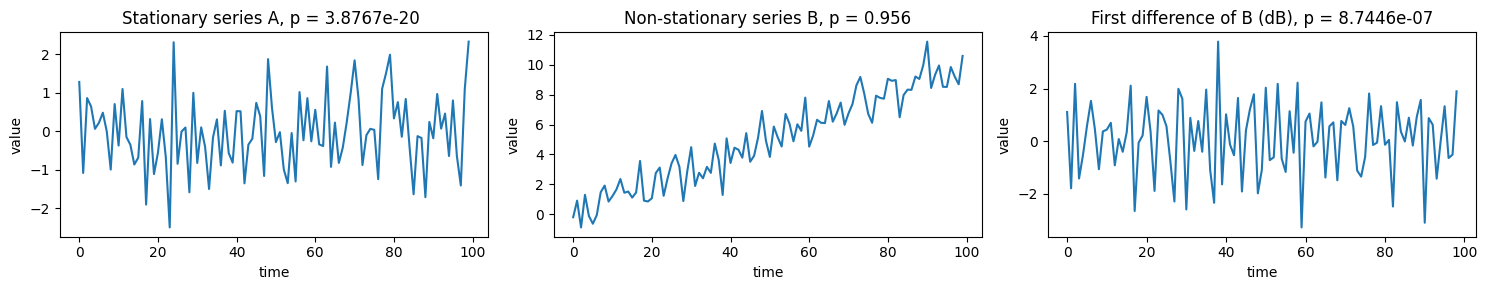

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))  # 3 panels side by side

axes[0].plot(A.values)
axes[0].set_title("Stationary series A, p = 3.8767e-20 ")
axes[0].set_xlabel("time"); axes[0].set_ylabel("value")

axes[1].plot(B.values)
axes[1].set_title("Non-stationary series B, p = 0.956")
axes[1].set_xlabel("time"); axes[1].set_ylabel("value")

axes[2].plot(dB.values)
axes[2].set_title("First difference of B (dB), p = 8.7446e-07")
axes[2].set_xlabel("time"); axes[2].set_ylabel("value")

plt.tight_layout()
plt.show()

Thus, our differencing method from earlier is valid, and we have a new stationary time series dB. 

We now need to test for co-integration to determine if our time series move together. 

We look at two time series of two securities' price levels. Call them $y_t, x_t$. Co-integration means we can find some $\beta$ such that $Y_t - \beta X_t$ is stationary. We can model this difference in terms of error.

$$
y_t = \hat{\alpha} + \hat{\beta}x_t + \hat{\varepsilon_t} \implies \hat{\varepsilon_t} = y_t - (\hat{\alpha} + \hat{\beta}x_t)
$$. 

Regressing, we get

$$
\Delta \varepsilon_t = \lambda\,\varepsilon_{t-1} + \sum_{j=1}^{k} \gamma_j\,\Delta \varepsilon_{t-j} + u_t
$$, 

See the derivation below, or skip for brevity. 

Start from an AR(p) for the residuals,
$$
\varepsilon_t \;=\; \phi_1\varepsilon_{t-1} + \phi_2\varepsilon_{t-2} + \cdots + \phi_p\varepsilon_{t-p} + u_t.
$$
This says the current residual is explained by a finite number of past residuals plus a new shock $u_t$.

Take first differences, $\Delta\varepsilon_t=\varepsilon_t-\varepsilon_{t-1}$
$$
\begin{aligned}
\Delta\varepsilon_t
&= \varepsilon_t - \varepsilon_{t-1} \\
&= \big(\phi_1\varepsilon_{t-1} + \phi_2\varepsilon_{t-2} + \cdots + \phi_p\varepsilon_{t-p} + u_t\big) - \varepsilon_{t-1} \\
&= (\phi_1-1)\varepsilon_{t-1} + \phi_2\varepsilon_{t-2} + \cdots + \phi_p\varepsilon_{t-p} + u_t.
\end{aligned}
$$

We do this to rewrite our series in terms of $\varepsilon_{t-1}$ which will allow us to test for a unit root.

We can further simplify the older terms $\varepsilon_{t-i}$ $i\ge2$ as a $t-1$  term minus accumulated differences:
$$
\varepsilon_{t-i} \;=\; \varepsilon_{t-1} - \sum_{j=0}^{i-2}\Delta\varepsilon_{t-1-j}.
$$


After substitution and collecting terms we get,
$$
\Delta\varepsilon_t
= \underbrace{\Big(\sum_{i=1}^p \phi_i - 1\Big)}_{\lambda}\,\varepsilon_{t-1}
+ \sum_{i=1}^{p-1}\underbrace{\gamma_i}_{\;-\sum_{j=i+1}^p \phi_j}\,\Delta\varepsilon_{t-i}
+ u_t
$$
Here $\lambda$ is the what we test later in our hypothesis test, and the $\gamma_i$ are combinations of AR coefficients that multiply lagged differences and capture the lagged relationship.

So explicitly:
$$
\lambda=\sum_{i=1}^p \phi_i - 1,\qquad
\gamma_i = -\sum_{j=i+1}^p \phi_j \quad (i=1,\dots,p-1).
$$

Thus, we have
$$
\Delta\hat\varepsilon_t \;=\; \lambda\,\hat\varepsilon_{t-1} + \sum_{i=1}^k \gamma_i\,\Delta\hat\varepsilon_{t-i} + \tilde u_t,
$$

Note that $u_t$ is the regression error in the AR(p) model. When we move to the ADF regression, $\hat{u_t}$ is the estimated regression residual. We want $u_t$ (and subsequently $\hat{u_t}$) to be approximately zero mean, serially uncorrelated (white noise), and finite variance.

That is why we include the lagged-difference terms $\sum_{i=1}^k\gamma_i\Delta\hat\varepsilon_{t-i}$: they “soak up” serial correlation so the remaining $\hat{u_t}$ is closer to white noise and inference on $\lambda$ is reliable.

Note that $k$ is the lag length that grows with the sample so that the ADF is valid. A small $k$ biases the test via serial correlation in errors. A large $k$ decreases the test's power. 

Then run an ADF test to see if $\varepsilon_t$ is $I(1) $ or $ I(0)$. We have the hypothesis test

$$
\begin{aligned}
H_{0} & :  \varepsilon_{t} \sim I(1) \implies y_{t} \ (\text{no  co-integration})  \\
H_{1} & : \varepsilon_{t} \sim I(0) \implies y_{t} \ (\text{co-integration})  \\
\end{aligned}
$$.

We can also state 

$$
\begin{aligned}
H_{0} & :  \lambda = 0  \\
H_{1} & : \lambda < 1  \\
\end{aligned}
$$

with the test statistic

$$
t_{\lambda} = \frac{\hat{\lambda}}{s_{\hat{\lambda}}}
$$.

We implement this in Python below with simulated data. 


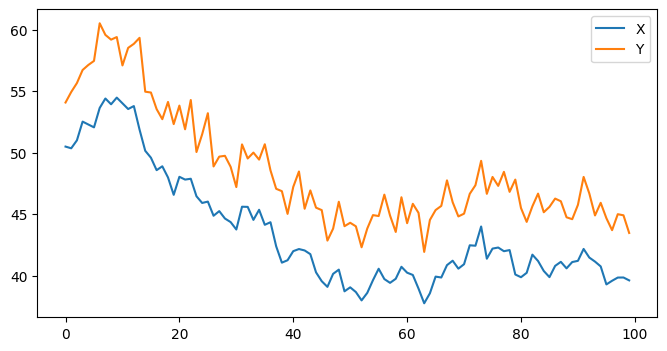

In [6]:
Xreturns = np.random.normal(0, 1, 100)

X = pd.Series(np.cumsum(
    Xreturns), name='X') + 50

noise = np.random.normal(0, 1, 100)
Y = X + 5 + noise
Y.name = 'Y'

pd.concat([X, Y], axis=1).plot(figsize=(8, 4))

plt.show()

We then plot the spread and test for co-integration.

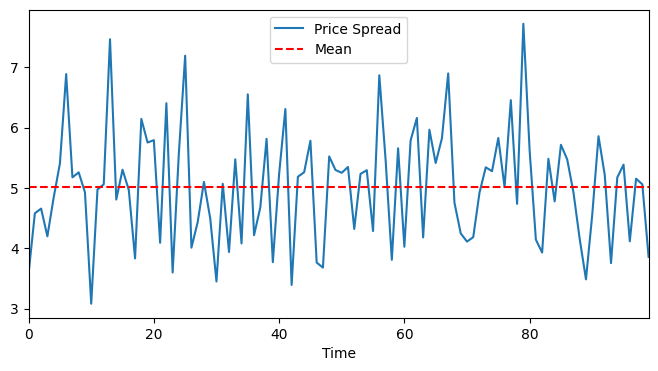

In [7]:
plt.figure(figsize=(8,4),)
(Y - X).plot()
plt.axhline((Y - X).mean(), color='red', linestyle='--') 
plt.xlabel('Time')
plt.xlim(0,99)
plt.legend(['Price Spread', 'Mean']);

In [8]:
from statsmodels.tsa.stattools import coint

score, pvalue, _ = coint(X,Y) # tests cointegration!
print(pvalue)

1.0672395686755154e-17


We see a significant p-value, and thus, the series are co-integrated.

##### **Implementation**

The idea now is that if we can find two securities that are co-integrated, we can engineer features to signal when one or both securities deviate from their typical co-movement. 

For example, if we have two healthcare stocks that are co-integrated, and one begins to abnormally move up, while the other moves down, a thesis could involve going long the underperforming stock and short the overperforming stock. 

Again, the key principle is based on mean reversion. We now implement this using yfinance. My strategy idea is to search for co-integrated commodities, as these various commodities are linked economically and will likely move together. We begin by scanning for these pairs then rank pairs based on p-values. 

In [9]:
# Co-integration screener for securities using yfinance 
import itertools
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

# Ticker banks
FUTS = [
    "GC=F","SI=F","CL=F","NG=F","HG=F","ZS=F","ZC=F","ZW=F",
    "KC=F","SB=F","CT=F","CC=F","PL=F","PA=F",
]
ETFS = [
    "GLD","SLV","USO","UNG","CPER","PPLT","PALL","DBA","DBC",
    "WEAT","CORN","SOYB","JO","BAL","NIB","SGG",
]

USE = ETFS  # switch to FUTS if preferred
START = "2015-01-01"
END   = None
INTERVAL = "1d"   



#  Download
raw = yf.download(USE, start=START, end=END, interval=INTERVAL,
                  auto_adjust=True, progress=False)

prices = raw["Close"].copy() if isinstance(raw.columns, pd.MultiIndex) else raw.copy()
if isinstance(prices, pd.Series):
    prices = prices.to_frame()

prices = prices.sort_index()


In [10]:
# Pairwise Co-integration
import itertools
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, coint
import statsmodels.api as sm

MIN_OBS    = 250       # minimum overlapping points per pair
REQUIRE_I1 = True      # skip pair if not I(1)
ADF_LVL_TH = 0.10      # ADF p-value threshold for levels (non-stationary if > this)
ADF_DIF_TH = 0.05      # ADF p-value threshold for first differences (stationary if < this)
COINT_TREND = "c"      # include constant ('c'), trend ('ct'), or none ('nc') in regression
# The c is like alpha in our regression y = alpha + beta x

# Function to run ADF test and return p-value
def adf_p(series, regression="c"):
    s = pd.Series(series).dropna().astype(float)   
    if len(s) < 40:                                         # skip if not enough data
        return np.nan
    try:
        _, p, *_ = adfuller(s.values,                       # run ADF test like above
                            regression=regression, 
                            autolag="AIC")
        return float(p)                                     # return p-value
    except Exception:
        return np.nan                                    


# Function to check if a series looks I(1)
def looks_I1(series, p_lvl_thresh=ADF_LVL_TH, p_diff_thresh=ADF_DIF_TH):
    """Heuristic I(1): non-stationary in levels, stationary in first differences."""
    s = pd.Series(series).dropna().astype(float)          
    if len(s) < 60:                                       
        return False
    p_lvl  = adf_p(s,       regression="c")               # ADF p-value on level data
    p_diff = adf_p(s.diff(), regression="c")              # ADF p-value on differenced data
    return (np.isfinite(p_lvl) and np.isfinite(p_diff)    # ensure valid results
            and p_lvl > p_lvl_thresh                      # non-stationary in levels
            and p_diff < p_diff_thresh)                   # stationary in first differences


# loop through all pairs, test for cointegration
def screen_cointegration_pairs(prices, min_obs=MIN_OBS, require_I1=REQUIRE_I1, trend=COINT_TREND):

    # Clean input dataframe
    df = prices.copy().sort_index().dropna(how="all")     # sort by date, drop all-NaN rows
    df = df.loc[:, (df > 0).any()]                        # drop cols with all  values < 0
    cols = list(df.columns)                               # store tickers

    rows = []
    for a, b in itertools.combinations(cols, 2):          # loop through all unique ticker pairs
        pair = df[[a, b]].dropna()                        # keep overlapping data only
        if len(pair) < min_obs:                           # skip if not enough overlap
            continue

        # Optional pre-check: both series must look I(1)
        if require_I1:
            if not (looks_I1(pair[a]) and looks_I1(pair[b])):  # skip if not I(1)
                continue

        # Engle–Granger cointegration test 
        try:
            stat, p, _ = coint(pair[a].values,       # run coint test between y=a and x=b
                                     pair[b].values,
                                     trend=trend)
        except Exception:
            continue

        # Estimate hedge ratio via OLS (not fully covered in this notebook, but neat)
        # this essentially lets you maintain mkt neutrality, compensate for the beta in the regression
        # think "how many y per x"
        try:
            X = sm.add_constant(pair[b].values)            # add intercept to x
            beta = float(sm.OLS(pair[a].values, X)         # regress y on x
                           .fit()
                           .params[1])                    # get slope 
        except Exception:
            beta = np.nan

        # Save
        rows.append({
            "y": a,                                        # dependent series
            "x": b,                                        # independent series
            "n_obs": int(len(pair)),                       # number of overlapping observations
            "p": float(p),                           # Engle-Granger p-value
            "stat": float(stat),                     # Engle-Granger test statistic
            "beta": beta                                   # hedge ratio estimate
        })


    # Compile and sort results
    res = pd.DataFrame(rows)
    if res.empty:
        print("No valid pairs found. Consider lowering MIN_OBS or set REQUIRE_I1=False.")
        return res

    res = res.sort_values("p").reset_index(drop=True)
    return res

# Run
results = screen_cointegration_pairs(prices, min_obs=250, require_I1=True)
print(results.head(10))

      y     x  n_obs         p      stat      beta
0   BAL    JO   1387  0.001902 -4.381879  1.029899
1   BAL  WEAT   1387  0.002120 -4.352238  7.846580
2   BAL   DBC   1387  0.013157 -3.809719  2.692056
3   BAL   DBA   1387  0.021765 -3.641245  5.115585
4   BAL  CORN   1387  0.025129 -3.591114  2.218057
5    JO  WEAT   1387  0.026712 -3.569500  5.967370
6  PPLT   SLV   2718  0.031247 -3.513152  1.100269
7   GLD   SLV   2718  0.041959 -3.403534  8.850039
8  CORN    JO   1387  0.096670 -3.059782  0.389841
9   DBC    JO   1387  0.099065 -3.048760  0.338253


      y     x  n_obs         p      stat      beta
0   BAL    JO   1387  0.001902 -4.381879  1.029899
1   BAL  WEAT   1387  0.002120 -4.352238  7.846580
2   BAL   DBC   1387  0.013157 -3.809719  2.692056
3   BAL   DBA   1387  0.021765 -3.641245  5.115585
4   BAL  CORN   1387  0.025129 -3.591114  2.218057
5    JO  WEAT   1387  0.026712 -3.569500  5.967370
6  PPLT   SLV   2718  0.031247 -3.513152  1.100269
7   GLD   SLV   2718  0.041959 -3.403534  8.850039
8  CORN    JO   1387  0.096670 -3.059782  0.389841
9   DBC    JO   1387  0.099065 -3.048760  0.338253


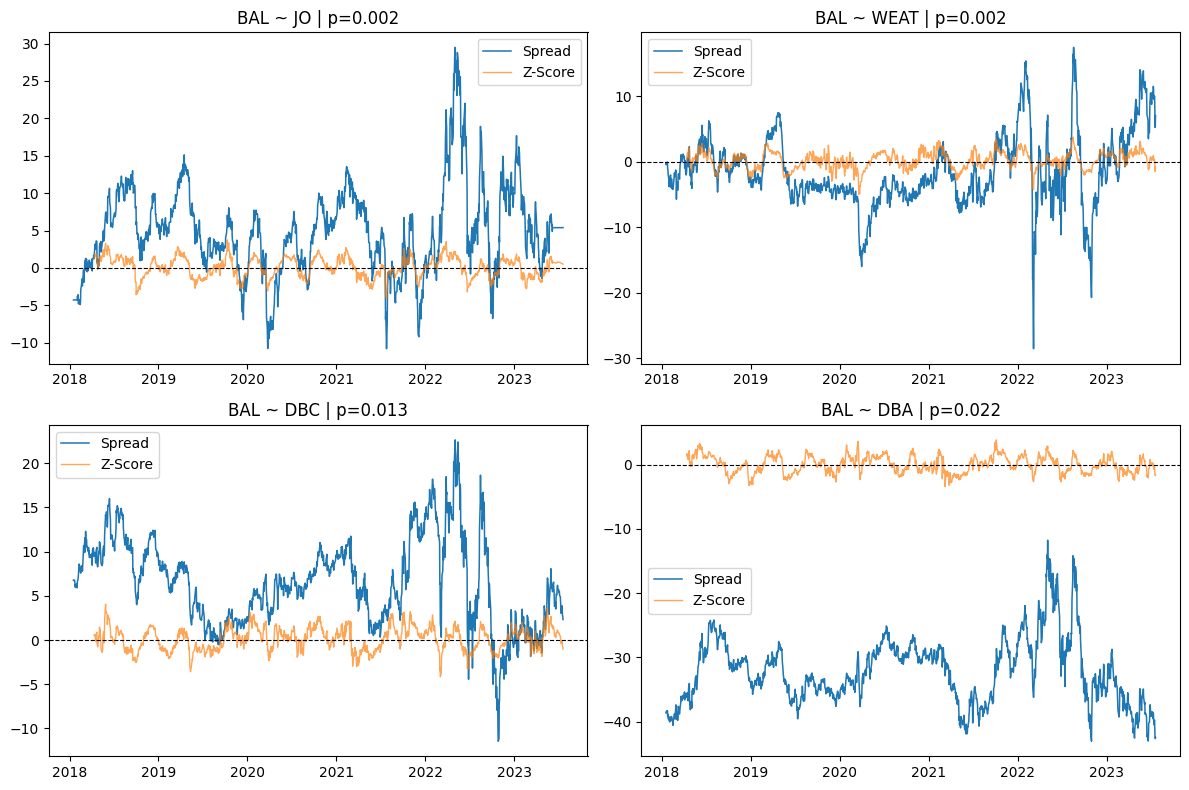

In [11]:
# Plot top cointegrated pairs' spreads and z-scores
import matplotlib.pyplot as plt

def plot_top_spreads(prices, results, top_n=4, roll_z=60):
    # Plot the spread and rolling z-score for the top_n cointegrated pairs

    if results.empty:
        print("No results to plot.")             # exit early if no results
        return

    n = min(top_n, len(results))                 # handle case with fewer than top_n pairs
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()                        # flatten axes for easy iteration

    for i in range(n):
        row = results.iloc[i]                    # select ith pair result
        y_tkr, x_tkr, beta = row["y"], row["x"], row["beta"]
        y = prices[y_tkr].dropna()               # clean Y 
        x = prices[x_tkr].dropna()               # clean X 
        idx = y.index.intersection(x.index)      # align by dates
        y, x = y.loc[idx], x.loc[idx]

        # Calculate spread and rolling z-score
        spread = y - beta * x                    # residual from equilibrium relationship
        z = (spread - spread.rolling(roll_z).mean()) / spread.rolling(roll_z).std()

        ax = axes[i]
        ax.plot(spread, label="Spread", lw=1.1)  # raw spread
        ax.plot(z, label="Z-Score", lw=1.0, alpha=0.7)  # standardized spread
        ax.axhline(0, color="k", ls="--", lw=0.8)       # zero mean line
        ax.set_title(f"{y_tkr} ~ {x_tkr} | p={row['p']:.3f}")  # pair label w/ p-value
        ax.legend(loc="best")

    # Remove unused subplot slots if fewer than 4 pairs plotted
    for j in range(n, 4):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


print(results.head(10))
plot_top_spreads(prices, results, top_n=4, roll_z=60)


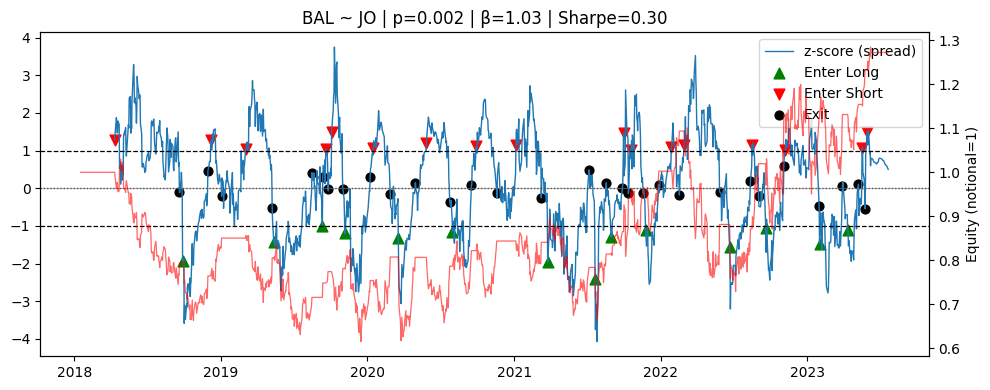

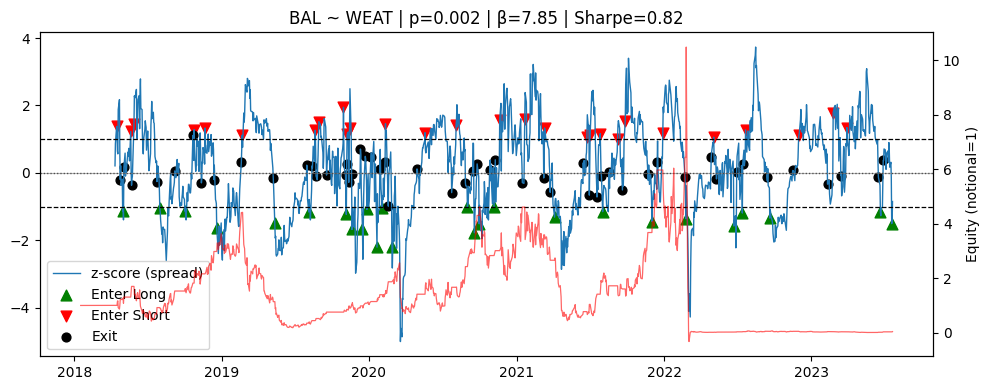

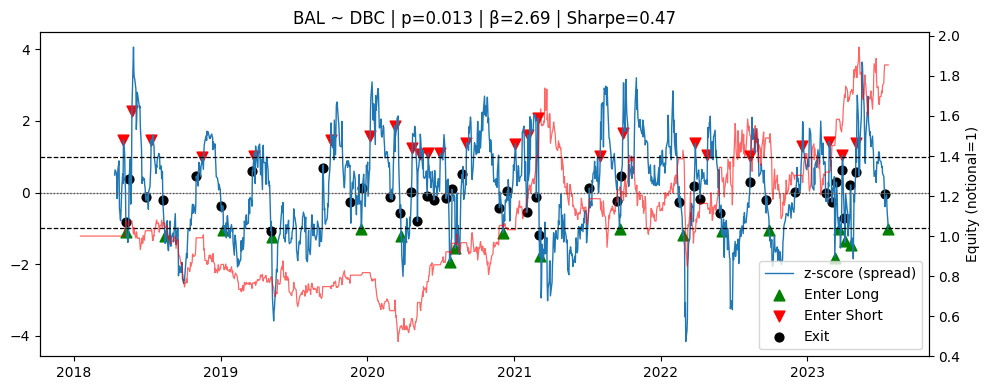

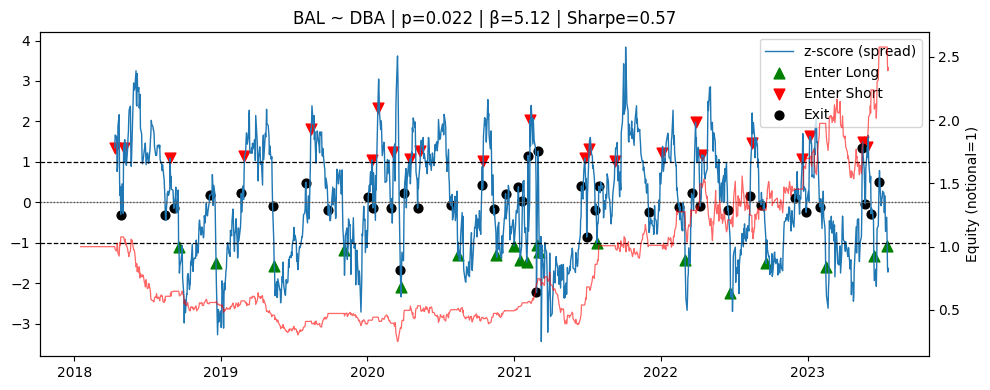

       pair         p      beta  ann_return       vol    sharpe
0    BAL/JO  0.001902  1.029899    4.467575  0.366038  0.302518
1  BAL/WEAT  0.002120  7.846580  -44.469117  1.980661  0.817481
2   BAL/DBC  0.013157  2.692056   11.881423  0.453697  0.473991
3   BAL/DBA  0.021765  5.115585   17.360516  0.551688  0.565519


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

def _clean_pair(y, x):
    #Align, remove NaN
    df = pd.DataFrame({"y": pd.Series(y, dtype=float),
                       "x": pd.Series(x, dtype=float)}).dropna()
    
    
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df


# model the spread = y - (alpha + beta x) (our error terms from earlier) and compute a z score
def spread_and_z(y, x, roll_z=60, alpha=None, beta=None):

    # Estimate  y = alpha + beta * x via OLS 
    # Form the spread S_t = y_t - (alpha + beta * x_t)
    # Standardize this spread with a rolling mean/std to get a z-score

    # roll_z controls the "memory" of the mean/std used for the z-score
    
    df = _clean_pair(y, x)
    if len(df) < max(roll_z + 5, 60):
        raise ValueError("Not enough data after dropping NaNs")

    # If alpha/beta not provided, fit them here (static hedge ratio)
    if alpha is None or beta is None:
        X = sm.add_constant(df["x"].values)            # [1, x]
        fit = sm.OLS(df["y"].values, X).fit()          # y ~ alpha + beta*x
        alpha, beta = float(fit.params[0]), float(fit.params[1])

    # Spread is just the residual from that regression
    S = (df["y"] - (alpha + beta * df["x"])).rename("spread")

    # Rolling mean / std so we can turn S into a standardized z-score
    mu = S.rolling(roll_z, min_periods=roll_z).mean()
    sd = S.rolling(roll_z, min_periods=roll_z).std(ddof=1)
    z = (S - mu) / sd
    return S, z, alpha, beta


### Enter long when z<-k, short wehen z>k, exit when z crosses 0
def trade_spread(y, x, roll_z=60, k=1.0, flat=0.0):
 
# create z score
    S, z, alpha, beta = spread_and_z(y, x, roll_z=roll_z)
    
    # Create the position in our spread space 
    pos = pd.Series(0, index=z.index, dtype=int)
    in_pos = 0
    for i in range(1, len(z)):
        zi = z.iloc[i]

        # flat -> enter on thresholds
        if in_pos == 0:
            if zi > +k: 
                in_pos = -1  # short
            elif zi < -k: 
                in_pos = +1  # long
        else:
            # if in a position -> exit when we revert back through the flat line
            if (in_pos == +1 and zi >= flat) or (in_pos == -1 and zi <= flat):
                in_pos = 0

        pos.iloc[i] = in_pos

    # Maintain market neutrality by hedging our beta (how many x offset one unit y)
    # note this is not dollar neutral, so this is on a per unit not price basis
    df = _clean_pair(y, x).loc[z.index]  
    ry = df["y"].pct_change().fillna(0.0)
    rx = df["x"].pct_change().fillna(0.0)

    # When long spread, earn (y_ret - beta * x_ret); reverse sign when short
    wY, wX = 1.0, float(beta)
    leg_ret = pos.shift(1).fillna(0) * ( wY*ry - np.sign(wX)*abs(wX)*rx )  # long y and short beta x when spread < mean, reverse if spread > mean

    # Build equity curve and basic stats (annualized)
    equity = (1.0 + leg_ret.replace([np.inf, -np.inf], np.nan).fillna(0.0)).cumprod()
    ann = (equity.iloc[-1] ** (252/len(equity)) - 1) if len(equity) > 10 else np.nan
    vol = leg_ret.std(ddof=1) * np.sqrt(252)
    sharpe = (leg_ret.mean()/leg_ret.std(ddof=1)*np.sqrt(252)) if leg_ret.std(ddof=1) > 0 else np.nan

    return {
        "alpha": alpha, "beta": beta, "z": z, "pos": pos, "equity": equity,
        "ann_return": float(ann) if np.isfinite(ann) else np.nan,
        "vol": float(vol) if np.isfinite(vol) else np.nan,
        "sharpe": float(sharpe) if np.isfinite(sharpe) else np.nan
    }
def run_top4_spread_strategy(prices, results, roll_z=60, k=1.0, flat=0.0):
    # Plot each pair individually with buy/sell markers
    top_n = min(4, len(results))
    if top_n == 0:
        print("No results.")
        return pd.DataFrame()

    rows = []
    for i in range(top_n):
        row = results.iloc[i]
        y_tkr, x_tkr = row["y"], row["x"]
        out = trade_spread(prices[y_tkr], prices[x_tkr],
                           roll_z=roll_z, k=k, flat=flat)

        z, eq, pos = out["z"], out["equity"], out["pos"]

        # --- Identify trade points ---
        pos_shift = pos.shift(1).fillna(0)
        enter_long = (pos == 1) & (pos_shift == 0)
        enter_short = (pos == -1) & (pos_shift == 0)
        exit_trade = (pos == 0) & (pos_shift != 0)

        # --- Create a new figure per pair ---
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(z, lw=1.0, label="z-score (spread)")
        ax.axhline(+k,   ls="--", lw=0.9, color="k")
        ax.axhline(-k,   ls="--", lw=0.9, color="k")
        ax.axhline(flat, ls=":",  lw=0.9, color="k")
        ax.axhline(0,    ls="-",  lw=0.8, color="gray", alpha=0.6)

        # --- Add markers for trades ---
        ax.scatter(z.index[enter_long], z[enter_long], marker="^", color="green", s=60, label="Enter Long")
        ax.scatter(z.index[enter_short], z[enter_short], marker="v", color="red", s=60, label="Enter Short")
        ax.scatter(z.index[exit_trade], z[exit_trade], marker="o", color="black", s=40, label="Exit")

        ax.set_title(f"{y_tkr} ~ {x_tkr} | p={row['p']:.3f} | β={out['beta']:.2f} | Sharpe={out['sharpe']:.2f}")
        ax.legend(loc="best")

        # Equity curve on secondary y-axis (in red)
        ax2 = ax.twinx()
        ax2.plot(eq, lw=0.9, alpha=0.6, color="red")
        ax2.set_ylabel("Equity (notional=1)")

        plt.tight_layout()
        plt.show()

        rows.append({
            "pair": f"{y_tkr}/{x_tkr}",
            "p": row["p"],
            "beta": out["beta"],
            "ann_return": out["ann_return"] * 100,
            "vol": out["vol"],
            "sharpe": out["sharpe"],
        })

    return pd.DataFrame(rows)



summary = run_top4_spread_strategy(prices, results, roll_z=60, k=1.0, flat=0.0)
print(summary)

# These graphs plot the equity curve (PnL) over time, as well as the spreadand positions taken.